# IPCC AR6 Emissions Scenarios

Projected CO2 under five Shared Socioeconomic Pathways, taken from the figure data behind the AR6
Synthesis Report. It is the only forward-looking source here: every other one records what happened.
The published pathways are emissions, and this loader converts them to concentrations so they share
an axis with the CO2 record and with any forecast built on it.

## Provenance

| Field | Value |
|---|---|
| Publisher | IPCC, distributed by NASA Socioeconomic Data and Applications Center |
| Source | <https://doi.org/10.7927/baxv-nj53> |
| License | Attribution 4.0 International (CC BY 4.0) |
| Citation | IPCC, 2024. IPCC AR6 Synthesis Report LR Cross-Section Box.2, Figure 1 (a). Palisades, New York: NASA Socioeconomic Data and Applications Center (SEDAC). <https://doi.org/10.7927/baxv-nj53> |
| Cache file | none to download; `ipcc_scenarios__reading=<hash>.parquet` once processed |
| Declaration checked | 2026-09-09 |

These are the fields of the `IPCC` declaration in `climate_risk/data/ipcc.py`. It is a
`VendoredSource` rather than a `DataSource`, because SEDAC was decommissioned in June 2025 and no
successor serves the workbook.

## Loading it

The scenario workbook ships inside the package, so the only thing fetched is the observed CO2 series
the projections are anchored to. The cache directory is your choice, and this page uses one named
`data` in the working directory.

In [1]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import climate_risk as cr

from climate_risk.plotting import configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [2]:
cache_dir = Path("data")

scenarios = cr.process_ipcc_scenarios(cache_dir)

## What you get

A polars frame of eleven columns. `year`, then the published emission rate per scenario as
`<scenario>_emissions` in GtCO2 per year, then the concentration it accumulates to as `<scenario>`
in parts per million. Most callers want the bare scenario columns.

In [3]:
scenarios.select("year", "SSP5-85_emissions", "SSP5-85").head()

year,SSP5-85_emissions,SSP5-85
i64,f64,f64
2020,44.426353,414.21
2021,45.653229,417.12323
2022,46.880105,420.036461
2023,48.106981,422.949691
2024,49.333856,425.862922


## Coverage

`describe` answers the span and the spread in one call, computed from the frame you just loaded.

In [4]:
scenarios.select("year", "SSP1-19", "SSP5-85").describe()

statistic,year,SSP1-19,SSP5-85
str,f64,f64,f64
"""count""",81.0,81.0,81.0
"""null_count""",0.0,0.0,0.0
"""mean""",2060.0,427.225282,607.772552
"""std""",23.526581,6.026298,139.173393
"""min""",2020.0,413.260022,414.21
"""25%""",2040.0,422.892103,483.484263
"""50%""",2060.0,429.255344,586.049531
"""75%""",2080.0,432.401643,723.930341
"""max""",2100.0,433.437171,871.700269


## A plot

The five pathways, in order of forcing. They share the observed 2020 concentration by construction,
which is why they fan out from one point rather than from a spread.

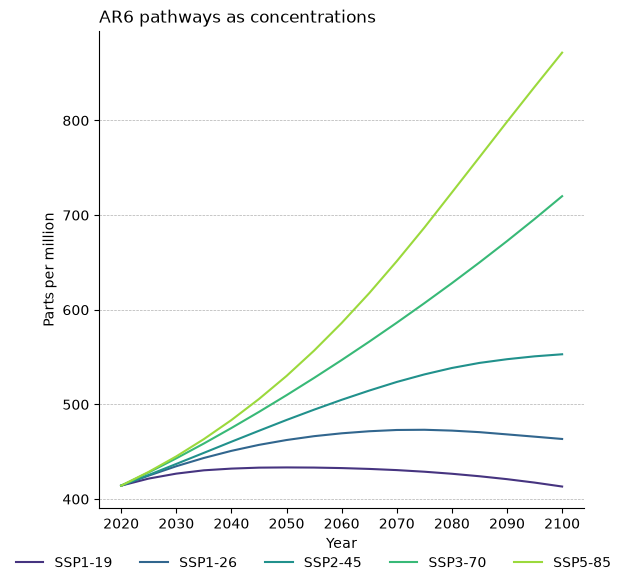

In [5]:
SCENARIOS = ["SSP1-19", "SSP1-26", "SSP2-45", "SSP3-70", "SSP5-85"]
shades = plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(SCENARIOS)))

figure, axis = plt.subplots(figsize=(5.5, 5.5))

for name, shade in zip(SCENARIOS, shades, strict=True):
    axis.plot(scenarios["year"], scenarios[name], color=shade, label=name)

axis.set_title("AR6 pathways as concentrations", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Parts per million")

handles, labels = axis.get_legend_handles_labels()
figure.legend(
    handles=handles,
    labels=labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=len(labels),
    frameon=False,
)

plt.show()

## Gotchas

*These are projections, not observations.* Every other source here records measurements. Putting
this beside them without saying so invites a reader to treat 2100 as data.

*The concentration is derived, and the derivation is approximate.* The workbook publishes emissions.
A published value is a rate covering the five-year step after it, so it becomes a quantity of CO2,
of which `AIRBORNE_FRACTION` reaches the atmosphere at `GTCO2_PER_PPM`. The airborne fraction is held
constant, and the real one rises with cumulative emissions, so the highest pathways come out low.
Read these as an indication of where a pathway goes, not as the concentrations AR6 reports.

*The frame carries the published rate as well.* The `<scenario>_emissions` columns are the workbook's
own GtCO2 per year, untouched. Selecting scenario columns by prefix picks up both those and the
concentrations.

*It depends on another loader.* `ANCHOR_YEAR` is 2020 and the concentration at that year comes from
`load_co2_data`, so a change to the Mauna Loa record moves every projected pathway with it.

*There is no history here.* Rows run 2020 to 2100. Years at or before the anchor contribute nothing
to the accumulation, so the published 2015 point does not survive.

*The workbook ships in the wheel.* SEDAC was decommissioned in June 2025, so nothing is fetched and
no URL enters the nightly reachability check. `climate_risk/data/vendored/ATTRIBUTION.md` carries the
redistribution notice.